<a href="https://www.kaggle.com/code/nicapotato/global-tech-startups-pipeline?scriptVersionId=340390063" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Guided Numeric Exploration — Global Tech Startups Pipeline
_Synthetic 25k-company panel: funding, burn, layoffs, AI adoption, and exit status_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [saitejabandaruin/global-tech-startups-pipeline](https://www.kaggle.com/datasets/saitejabandaruin/global-tech-startups-pipeline)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Landscape](#Univariate)** <br>
**4. [Funding by Domain and Stage](#Funding)** <br>
**5. [ARR by Domain and Valuation](#ARR)** <br>
**6. [Layoffs, Burn, and Headcount](#Layoffs)** <br>
**7. [Outcomes: Acquisition Status](#Outcomes)** <br>
**8. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
A **synthetic** global tech/AI startup panel (25,000 rows) framed around ZIRP over-hiring, the GenAI boom, and a 2024–2025 tech winter. Columns cover domain, geo, funding stage, capital metrics, runway/burn, headcount peak→2026, layoffs, investor tier, AI adoption, and `Acquisition_Status`.

`AI_Adoption_Level` is ~10% null — I will **not** impute it; nulls stay visible as their own group where plotted. Associations describe the generator's narrative, not real company filings.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "global_tech_startups_2026.csv"
KAGGLE_SLUG = "saitejabandaruin/global-tech-startups-pipeline"
EXPECTED_COLS = [
    "Company_ID", "Domain", "Founding_Year", "Country", "City", "Funding_Stage",
    "Total_Funding_USD_Millions", "Valuation_USD_Millions", "Revenue_ARR_Millions",
    "Monthly_Burn_Rate_Millions", "Runway_Months_2024", "Peak_Headcount_2023",
    "Layoffs_2024_2025", "Current_Headcount_2026", "Investor_Tier",
    "AI_Adoption_Level", "Acquisition_Status",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(CSV_BASENAME))
        assert hits, f"{CSV_BASENAME} not under /kaggle/input"
        return hits[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(CSV_BASENAME))
    assert hits, f"expected {CSV_BASENAME} under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 25000, f"expected 25000 rows, got {len(df)}"

n_dup_ids = int(df["Company_ID"].duplicated().sum())
print("Duplicate Company_ID rows:", n_dup_ids)
assert n_dup_ids <= 1, f"unexpected duplicate ID volume: {n_dup_ids}"

df["headcount_change"] = df["Current_Headcount_2026"] - df["Peak_Headcount_2023"]
df["layoff_rate"] = df["Layoffs_2024_2025"] / df["Peak_Headcount_2023"].clip(lower=1)
df["AI_Adoption_Level_filled"] = df["AI_Adoption_Level"].fillna("Unknown")

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("AI_Adoption_Level null share: {:.1%}".format(df["AI_Adoption_Level"].isna().mean()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Acquisition_Status:", df["Acquisition_Status"].value_counts().to_dict())


CSV: /kaggle/input/datasets/saitejabandaruin/global-tech-startups-pipeline/global_tech_startups_2026.csv
Duplicate Company_ID rows: 1
Missing Values: 2436
AI_Adoption_Level null share: 9.7%
Dataframe Dimension: 25000 Rows, 20 Columns
Acquisition_Status: {'Independent': 15656, 'Closed': 4944, 'Acquired': 2621, 'Acquired (Fire Sale)': 1120, 'IPO': 659}


**Code Explanation and Reasoning:** <br>
Shape and schema are asserted. The single known `Company_ID` collision is allowed explicitly (≤1 duplicate) rather than pretending IDs are a perfect primary key. AI adoption nulls become label `Unknown` only for plotting — the original column stays untouched.


In [3]:
df.sample(5, random_state=7)


,Company_ID,Domain,Founding_Year,Country,City,Funding_Stage,Total_Funding_USD_Millions,Valuation_USD_Millions,Revenue_ARR_Millions,Monthly_Burn_Rate_Millions,Runway_Months_2024,Peak_Headcount_2023,Layoffs_2024_2025,Current_Headcount_2026,Investor_Tier,AI_Adoption_Level,Acquisition_Status,headcount_change,layoff_rate,AI_Adoption_Level_filled
21752,E43141E6,Web3/Crypto,2015,USA,Austin,Series A,10.92,67.38,2.37,0.52,17.6,35,18,17,Tier 3 (Angel/Seed),Medium,Closed,-18,0.514286,Medium
7208,3F830EB6,Generative AI,2013,India,Mumbai,Seed,2.55,26.78,1.80,0.63,3.5,41,0,41,Corporate VC (e.g. Google Ventures),High,Independent,0,0.000000,High
17058,471C37E0,SpaceTech,2018,India,Hyderabad,Post-IPO,1916.70,14053.58,684.40,127.83,15.0,8064,403,7661,Tier 2 (Mid-size VC),Medium,Independent,-403,0.049975,Medium
20754,5F599C4E,Generative AI,2019,Israel,Tel Aviv,Seed,5.62,55.16,6.30,0.82,6.1,60,0,60,Tier 3 (Angel/Seed),NaN,Independent,0,0.000000,Unknown
22505,D00574AE,FinTech,2020,USA,San Francisco,Series A,0.00,13.85,1.20,0.08,0.0,6,0,6,Bootstrapped,Medium,Closed,0,0.000000,Medium


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Null", ascending=False))
df[["Total_Funding_USD_Millions", "Valuation_USD_Millions", "Revenue_ARR_Millions", "Monthly_Burn_Rate_Millions", "Runway_Months_2024", "Layoffs_2024_2025"]].describe().T.round(2)


,Column,Unique,Null
15,AI_Adoption_Level,4,2436
0,Company_ID,24999,0
2,Founding_Year,14,0
1,Domain,10,0
3,Country,10,0
4,City,29,0
6,Total_Funding_USD_Millions,8637,0
5,Funding_Stage,6,0
8,Revenue_ARR_Millions,6505,0
9,Monthly_Burn_Rate_Millions,2203,0


,count,mean,std,min,25%,50%,75%,max
Total_Funding_USD_Millions,25000.0,61.76,222.87,0.00,2.07,8.65,37.29,8037.67
Valuation_USD_Millions,25000.0,474.87,1789.90,1.02,29.14,72.90,278.18,65215.30
Revenue_ARR_Millions,25000.0,34.47,152.30,0.04,1.82,4.89,18.20,6370.04
Monthly_Burn_Rate_Millions,25000.0,3.23,10.90,0.05,0.43,0.71,2.28,690.08
Runway_Months_2024,25000.0,12.30,10.20,0.00,4.00,10.80,17.60,106.10
Layoffs_2024_2025,25000.0,31.31,219.03,0.00,0.00,0.00,16.00,24492.00


**Interpretation** <br>
Funding and valuation are heavy-tailed. Layoffs and headcount change operationalize the tech-winter story. Only AI adoption carries meaningful missingness.


# **3. Univariate Landscape:** <a id="Univariate"></a>


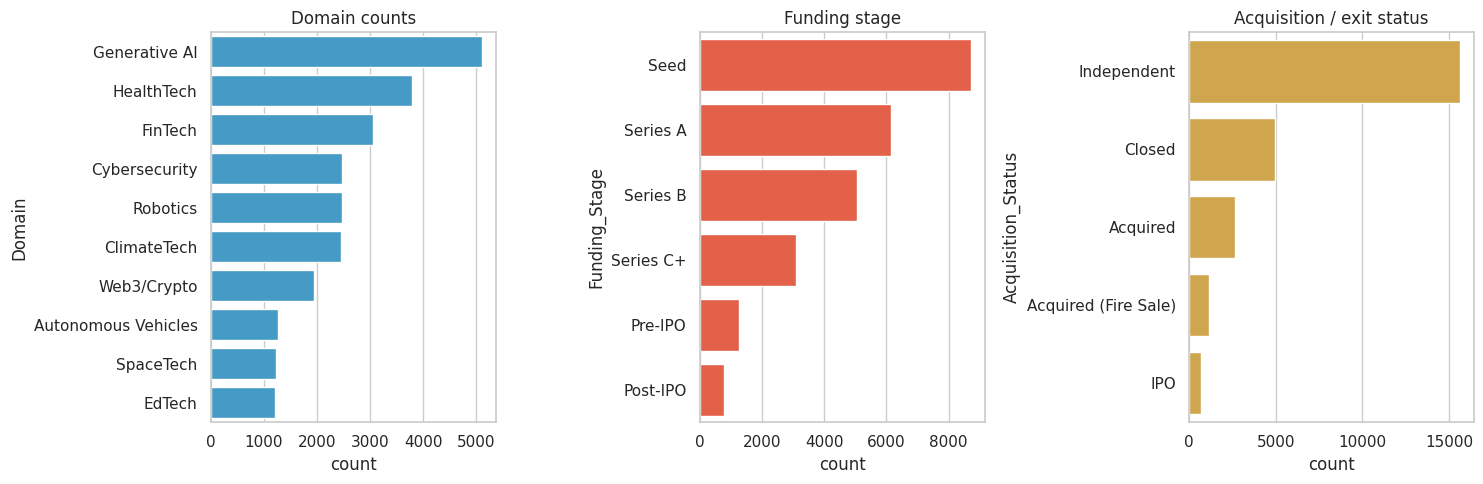

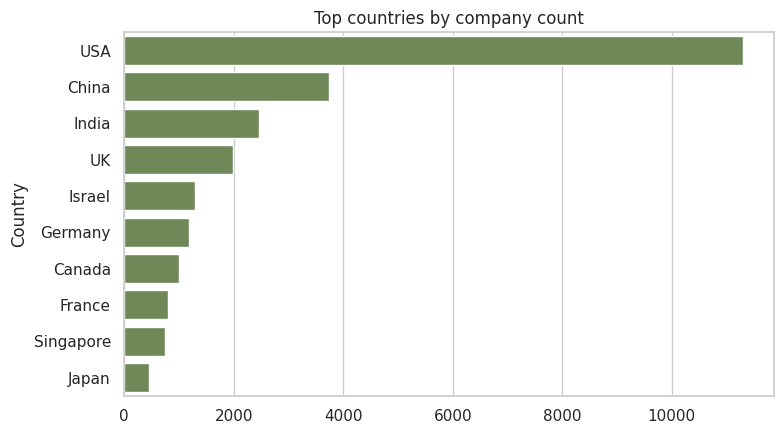

In [5]:
f, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(data=df, y="Domain", order=df["Domain"].value_counts().index, ax=ax[0], color="#30a2da")
ax[0].set_title("Domain counts")
stage_order = ["Seed", "Series A", "Series B", "Series C+", "Pre-IPO", "Post-IPO"]
stage_order = [s for s in stage_order if s in set(df["Funding_Stage"])]
sns.countplot(data=df, y="Funding_Stage", order=stage_order, ax=ax[1], color="#fc4f30")
ax[1].set_title("Funding stage")
sns.countplot(data=df, y="Acquisition_Status", order=df["Acquisition_Status"].value_counts().index, ax=ax[2], color="#e5ae38")
ax[2].set_title("Acquisition / exit status")
plt.tight_layout()
plt.show()

top_countries = df["Country"].value_counts().head(10)
f, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, color="#6d904f")
ax.set_title("Top countries by company count")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Domain and stage mix show what the generator over-samples (GenAI, Seed). Exit status is the outcome surface for later crosstabs; Independent should dominate if the winter is selective.


# **4. Funding by Domain and Stage:** <a id="Funding"></a>


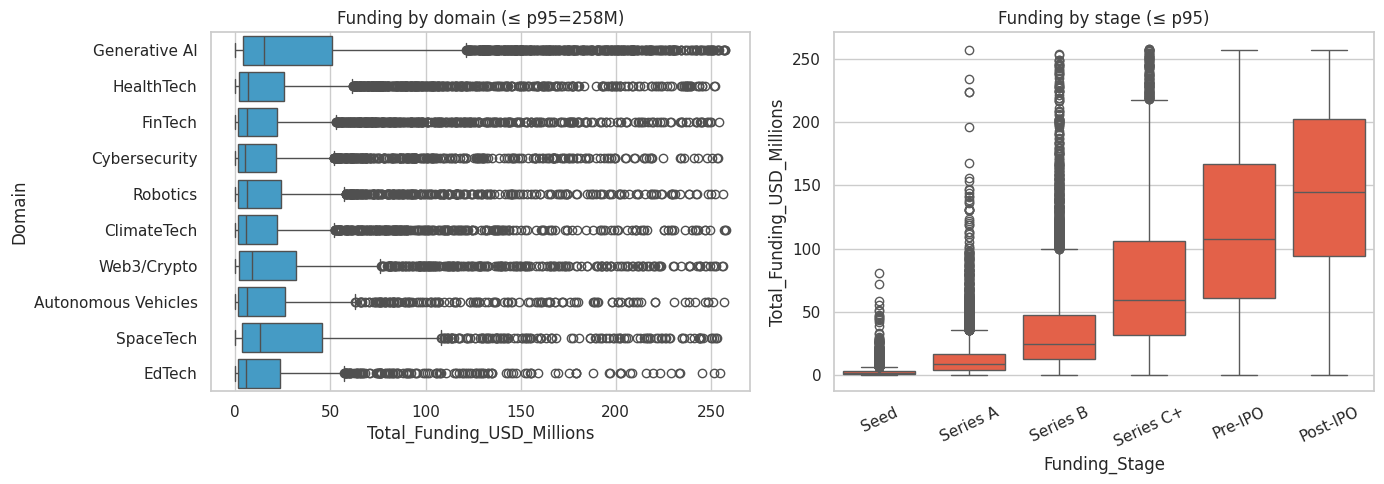

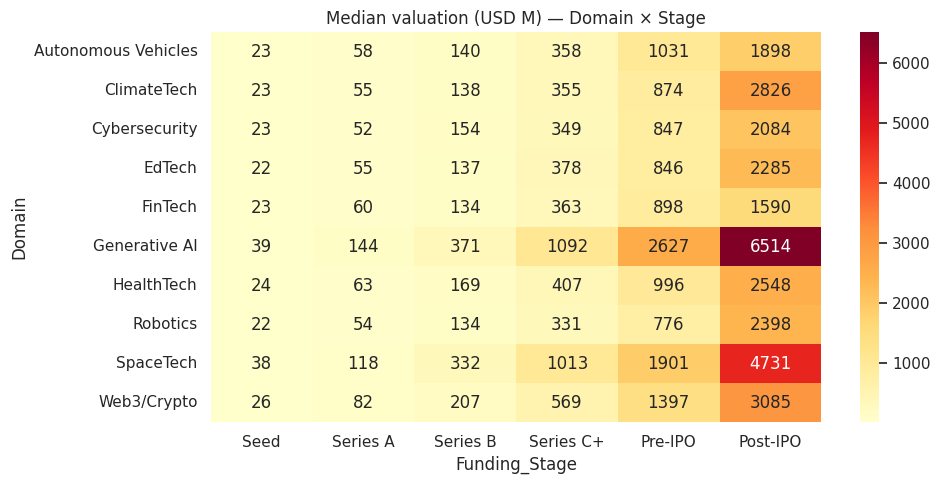

In [6]:
# Cap extreme tails for readable boxplots
fund_cap = df["Total_Funding_USD_Millions"].quantile(0.95)
plot_df = df[df["Total_Funding_USD_Millions"] <= fund_cap].copy()
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=plot_df, y="Domain", x="Total_Funding_USD_Millions",
    order=df["Domain"].value_counts().index, ax=ax[0], color="#30a2da",
)
ax[0].set_title(f"Funding by domain (≤ p95={fund_cap:.0f}M)")
sns.boxplot(
    data=plot_df, x="Funding_Stage", y="Total_Funding_USD_Millions",
    order=stage_order, ax=ax[1], color="#fc4f30",
)
ax[1].set_title("Funding by stage (≤ p95)")
ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

med = (
    df.groupby(["Domain", "Funding_Stage"])["Valuation_USD_Millions"]
    .median()
    .unstack()
)
# keep common stages
med = med.reindex(columns=[c for c in stage_order if c in med.columns])
f, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(med, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
ax.set_title("Median valuation (USD M) — Domain × Stage")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Stage boxes should rise left-to-right if the capital ladder is coherent. Domain × stage valuation heatmaps highlight whether GenAI is shielded relative to Web3/Climate at the same stage.


# **5. ARR by Domain and Valuation:** <a id="ARR"></a>


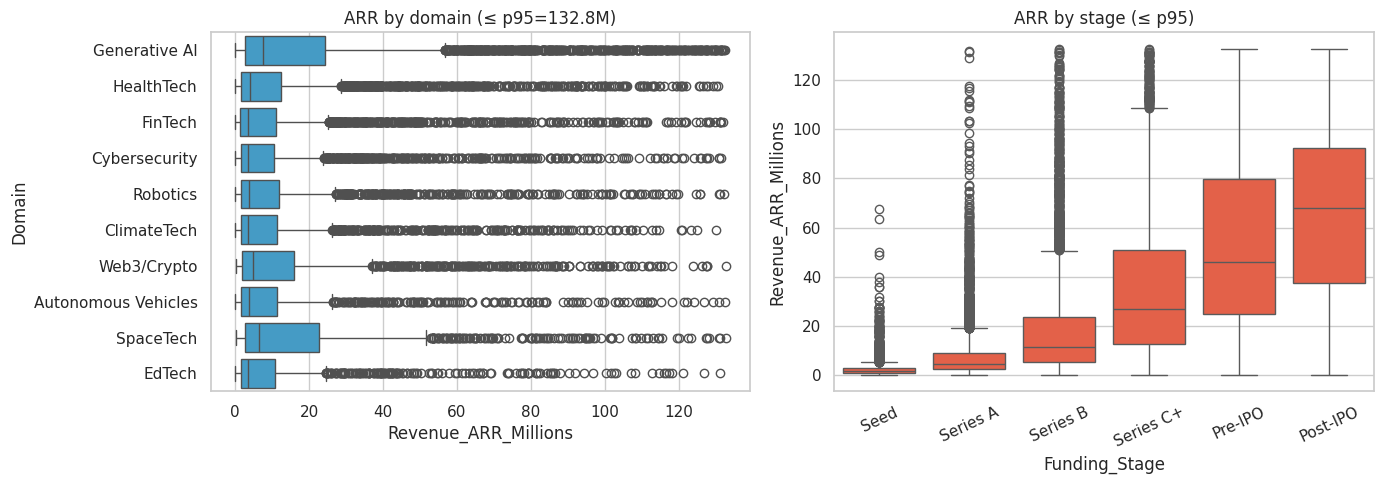

,n,arr_median,arr_mean,val_median,multiple_median,multiple_mean
Domain,,,,,,
Generative AI,5107,9.50,70.15,150.91,17.48,17.46
SpaceTech,1234,8.02,55.60,125.50,17.03,17.33
Web3/Crypto,1934,5.37,33.35,80.38,17.76,17.47
HealthTech,3779,4.44,23.78,64.64,17.67,17.48
Autonomous Vehicles,1271,3.90,23.37,59.22,17.97,17.75
Robotics,2476,3.86,23.62,55.49,17.48,17.55
FinTech,3045,3.76,19.58,57.71,17.63,17.63
ClimateTech,2459,3.74,23.22,54.42,17.58,17.49
EdTech,1216,3.69,21.60,55.32,17.17,17.37


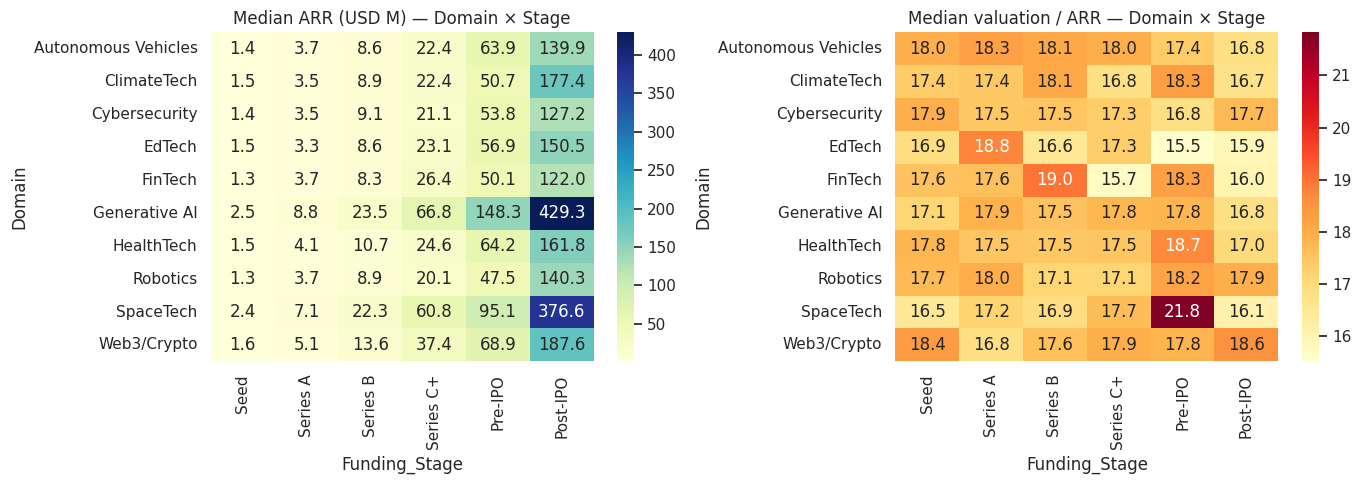

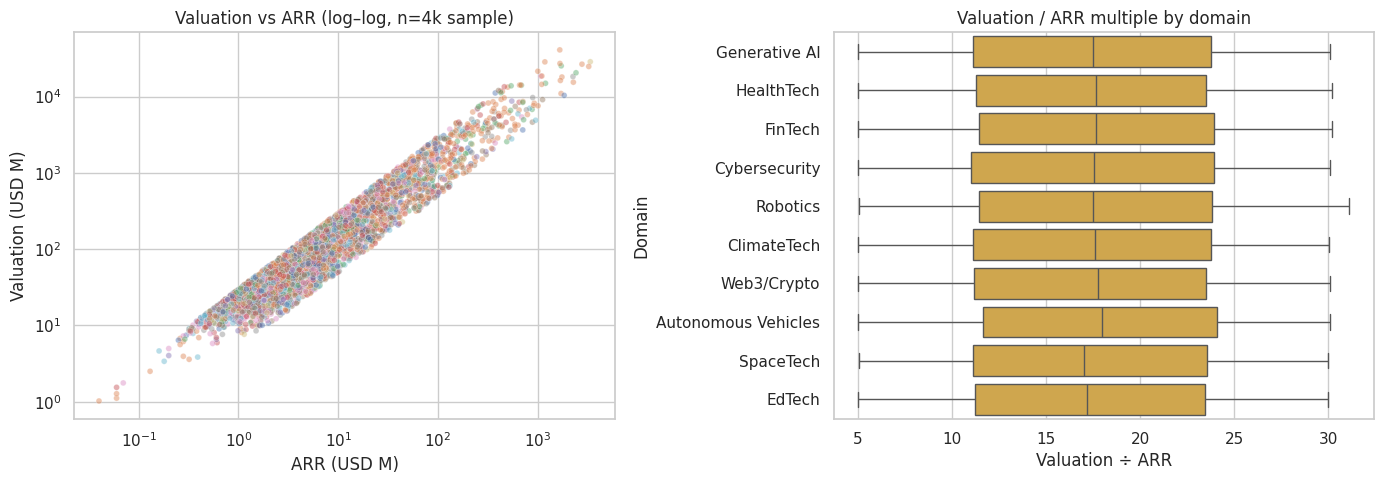

,count,median,mean
Funding_Stage,,,
Seed,8728,17.54,17.51
Series A,6133,17.68,17.59
Series B,5041,17.56,17.51
Series C+,3094,17.34,17.30
Pre-IPO,1244,17.91,17.69
Post-IPO,760,16.92,17.21


Spearman(ARR, Valuation) = 0.943
Multiple range: [5.0, 31.1]; median=17.6


In [7]:
# Revenue ARR deep dive: domain structure, stage ladder, and valuation multiples
assert (df["Revenue_ARR_Millions"] > 0).all(), "ARR must be positive for valuation / ARR multiples"
df["valuation_arr_multiple"] = df["Valuation_USD_Millions"] / df["Revenue_ARR_Millions"]

arr_cap = df["Revenue_ARR_Millions"].quantile(0.95)
arr_plot = df[df["Revenue_ARR_Millions"] <= arr_cap].copy()
domain_order = df["Domain"].value_counts().index

f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(
    data=arr_plot, y="Domain", x="Revenue_ARR_Millions",
    order=domain_order, ax=ax[0], color="#30a2da",
)
ax[0].set_title(f"ARR by domain (≤ p95={arr_cap:.1f}M)")
sns.boxplot(
    data=arr_plot, x="Funding_Stage", y="Revenue_ARR_Millions",
    order=stage_order, ax=ax[1], color="#fc4f30",
)
ax[1].set_title("ARR by stage (≤ p95)")
ax[1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# Domain summary: level of ARR and how the market prices it
arr_by_domain = (
    df.groupby("Domain")
    .agg(
        n=("Company_ID", "size"),
        arr_median=("Revenue_ARR_Millions", "median"),
        arr_mean=("Revenue_ARR_Millions", "mean"),
        val_median=("Valuation_USD_Millions", "median"),
        multiple_median=("valuation_arr_multiple", "median"),
        multiple_mean=("valuation_arr_multiple", "mean"),
    )
    .round(2)
    .sort_values("arr_median", ascending=False)
)
display(arr_by_domain)

# Median ARR and valuation/ARR multiple — Domain × Stage
arr_med = (
    df.groupby(["Domain", "Funding_Stage"])["Revenue_ARR_Millions"]
    .median()
    .unstack()
)
arr_med = arr_med.reindex(columns=[c for c in stage_order if c in arr_med.columns])
mult_med = (
    df.groupby(["Domain", "Funding_Stage"])["valuation_arr_multiple"]
    .median()
    .unstack()
)
mult_med = mult_med.reindex(columns=[c for c in stage_order if c in mult_med.columns])

f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(arr_med, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax[0])
ax[0].set_title("Median ARR (USD M) — Domain × Stage")
sns.heatmap(mult_med, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax[1])
ax[1].set_title("Median valuation / ARR — Domain × Stage")
plt.tight_layout()
plt.show()

# ARR vs valuation: log-log scatter (sample for readability) + domain-colored trend
scatter_df = df.sample(n=4000, random_state=7)
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=scatter_df, x="Revenue_ARR_Millions", y="Valuation_USD_Millions",
    hue="Domain", alpha=0.45, s=18, ax=ax[0], legend=False,
)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_title("Valuation vs ARR (log–log, n=4k sample)")
ax[0].set_xlabel("ARR (USD M)")
ax[0].set_ylabel("Valuation (USD M)")

sns.boxplot(
    data=df, y="Domain", x="valuation_arr_multiple",
    order=domain_order, ax=ax[1], color="#e5ae38",
)
ax[1].set_title("Valuation / ARR multiple by domain")
ax[1].set_xlabel("Valuation ÷ ARR")
plt.tight_layout()
plt.show()

# Stage-level multiple compression (does later capital pay less per $ ARR?)
stage_mult = (
    df.groupby("Funding_Stage")["valuation_arr_multiple"]
    .agg(["count", "median", "mean"])
    .reindex(stage_order)
    .round(2)
)
display(stage_mult)

rho_spearman = stats.spearmanr(df["Revenue_ARR_Millions"], df["Valuation_USD_Millions"]).statistic
print(f"Spearman(ARR, Valuation) = {rho_spearman:.3f}")
print(
    "Multiple range: [{:.1f}, {:.1f}]; median={:.1f}".format(
        df["valuation_arr_multiple"].min(),
        df["valuation_arr_multiple"].max(),
        df["valuation_arr_multiple"].median(),
    )
)


**How to Interpret:** <br>
ARR boxes by domain show which sectors the generator treats as revenue-heavy (expect GenAI / SpaceTech above EdTech / Cyber). Stage boxes should climb if ARR is encoded with the funding ladder. The Domain × Stage ARR heatmap separates *level* of revenue from the valuation/ARR heatmap, which answers whether a domain is *priced* richer at the same stage. Log–log valuation vs ARR should look near-linear if the generator ties markups to revenue; domain boxplots of the multiple then show residual pricing skew after that link.


# **6. Layoffs, Burn, and Headcount:** <a id="Layoffs"></a>


Share with layoffs > 0: 38.7%
Share headcount shrink vs peak: 38.7%


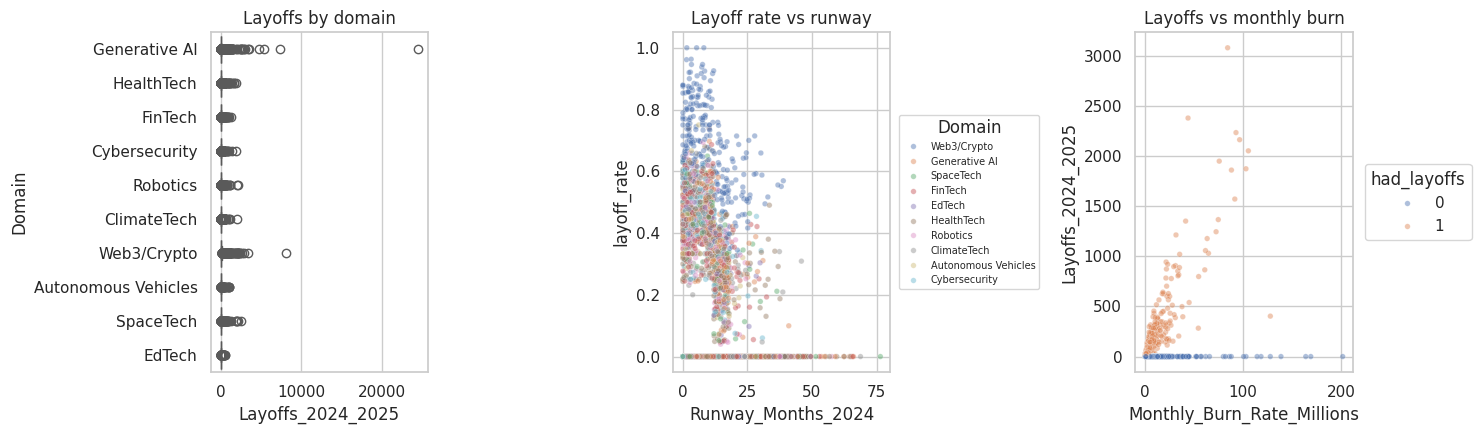

,Layoffs_2024_2025,Runway_Months_2024,Monthly_Burn_Rate_Millions,had_layoffs
Domain,,,,
Web3/Crypto,104.46,12.73,3.16,0.83
ClimateTech,19.23,11.06,2.16,0.40
HealthTech,22.23,11.57,2.48,0.39
Robotics,21.20,11.09,2.26,0.39
FinTech,19.39,11.09,2.08,0.39
Autonomous Vehicles,21.81,11.34,2.31,0.39
EdTech,17.36,11.01,2.09,0.38
Cybersecurity,18.17,10.70,2.03,0.38
SpaceTech,41.73,15.03,4.63,0.37


In [8]:
df["had_layoffs"] = (df["Layoffs_2024_2025"] > 0).astype(int)
print("Share with layoffs > 0: {:.1%}".format(df["had_layoffs"].mean()))
print("Share headcount shrink vs peak: {:.1%}".format((df["headcount_change"] < 0).mean()))

f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(
    data=df, y="Domain", x="Layoffs_2024_2025",
    order=df["Domain"].value_counts().index, ax=ax[0], color="#fc4f30",
)
ax[0].set_title("Layoffs by domain")
sns.scatterplot(
    data=df.sample(4000, random_state=7),
    x="Runway_Months_2024", y="layoff_rate", hue="Domain", ax=ax[1], alpha=0.45, s=16,
)
ax[1].set_title("Layoff rate vs runway")
ax[1].legend(title="Domain", bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=7)
sns.scatterplot(
    data=df.sample(4000, random_state=7),
    x="Monthly_Burn_Rate_Millions", y="Layoffs_2024_2025",
    hue="had_layoffs", ax=ax[2], alpha=0.45, s=16,
)
ax[2].set_title("Layoffs vs monthly burn")
ax[2].legend(title="had_layoffs", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

display(
    df.groupby("Domain")[["Layoffs_2024_2025", "Runway_Months_2024", "Monthly_Burn_Rate_Millions", "had_layoffs"]]
    .mean()
    .sort_values("had_layoffs", ascending=False)
    .round(2)
)


**How to Interpret:** <br>
Short runway and high burn should associate with more layoffs if the winter narrative is encoded. Domain mean tables show which sectors the generator punishes hardest.


# **7. Outcomes: Acquisition Status:** <a id="Outcomes"></a>


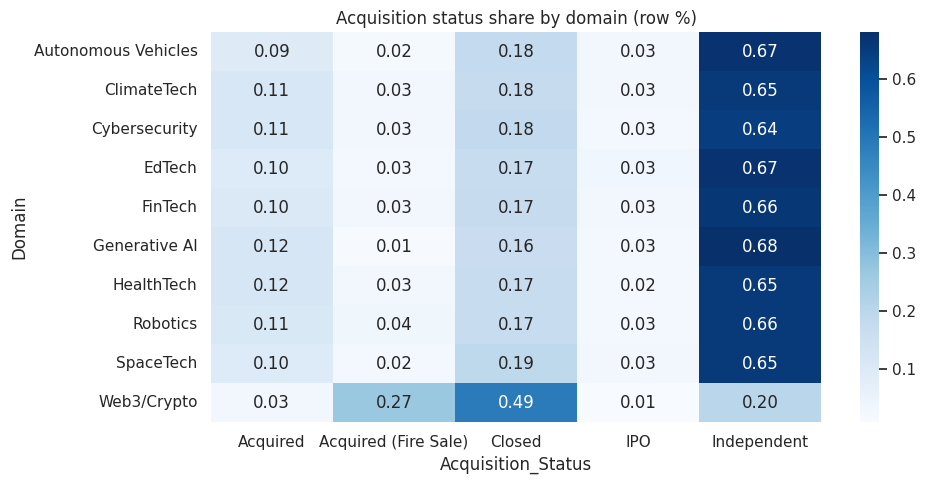

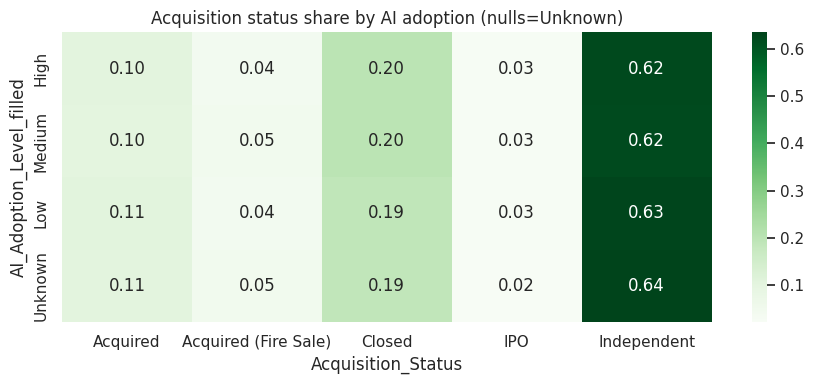

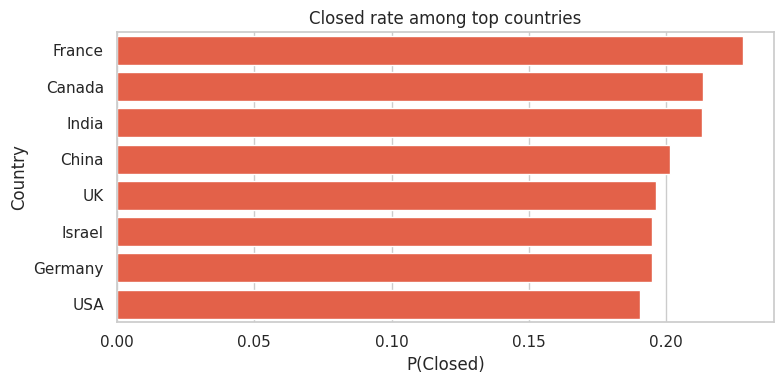

In [9]:
# Crosstab rates
ct = pd.crosstab(df["Domain"], df["Acquisition_Status"], normalize="index")
f, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Acquisition status share by domain (row %)")
plt.tight_layout()
plt.show()

ai_order = ["High", "Medium", "Low", "Unknown"]
ct2 = pd.crosstab(df["AI_Adoption_Level_filled"], df["Acquisition_Status"], normalize="index").reindex(ai_order)
f, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(ct2, annot=True, fmt=".2f", cmap="Greens", ax=ax)
ax.set_title("Acquisition status share by AI adoption (nulls=Unknown)")
plt.tight_layout()
plt.show()

top_c = df["Country"].value_counts().head(8).index
sub = df[df["Country"].isin(top_c)]
closed_rate = sub.groupby("Country")["Acquisition_Status"].apply(lambda s: (s == "Closed").mean()).sort_values(ascending=False)
f, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=closed_rate.values, y=closed_rate.index, ax=ax, color="#fc4f30")
ax.set_title("Closed rate among top countries")
ax.set_xlabel("P(Closed)")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Row-normalized heatmaps compare outcome mix within domain or AI-adoption band. `Unknown` AI adoption is kept as its own row so missingness is not hidden. Country closed rates need count context — small markets can look extreme.


# **8. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic post-ZIRP / GenAI / tech-winter startup panel with funding, labor, and exit labels.

**Working takeaways:** <br>
- Domain and stage structure the capital story; GenAI vs Web3 contrasts are first-class.
- ARR is domain-skewed (GenAI / SpaceTech lead medians) and climbs with stage; valuation tracks ARR tightly on a log scale.
- Valuation / ARR multiples compress at later stages and differ by domain — stage-controlled heatmaps matter more than raw averages.
- Layoffs track burn/runway/headcount shrink in the generator.
- Do not impute AI adoption; treat nulls as Unknown for group plots only.

**Open follow-ups:** <br>
- Multinomial model of Acquisition_Status with stage + burn + AI adoption + ARR multiple.
